In [298]:
import numpy as np
from numpy import pi
import random
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
import ipywidgets as widgets


# Introduction to Quantum Walks


TODO:
* Intro to Quantum Walks (:D)
* Discrete Time and Continuous Time Quantum Walks (:D)
* Simulation of Quantum Walks (1D, 2D, (maybe 3D) cases)
* Reproduce results about bias in Quantum walks and show how you can change it to fix this problem
* Figures on probability distributions for classical and quantum and show bias in quantum (make it interactive/animation)
* Potential real-life use case


## What are Quantum Walks?

Quantum walks are the quantum equivalent of the classical random walk. The main idea behind random walks is that there is a walker living in some space, for example in a line, 2D, 3D grid, or in a graph, and move in its environment by randomly picking where to go. For example in a 2D grid the walker will either walk left, right, up or down, and in a graph it will randomly choose which adjacent edges to traverse [2][4].

Quantum Walks are used in for example Algorithm-Design (such as finding collisions) and also are shown to be able to implement universal quantum computing [1][2].

Below are two types of types of Quantum Walks: Discrete-Time Quantum Walks (DTQW) and Continuous-Time Quantum Walks (CTQW), which are different in how the evolution of the walker's state happens (either in discrete steps, or in continuous evolution) [1].

## Discrete-Time Quantum Walks


There exist different types of discrete quantum walk models, but here we will simply present the coin-based type, as it is what one generally refers to DTQW as [1].
The coin-based quantum walker contains two registers: $$ |x\rangle|c\rangle  $$

Where $|x\rangle$ is the current position our walker is in and $|c\rangle$ is the coin state which holds the direction (or the coin state).

To interact with the walker, we implement two kinds of operations on the registers: the coin operator C which interacts only with state $|c\rangle$ (so the operation is $C ⊗ I_S$) and the shift operator S which is applied to both $|x\rangle$ and $|c\rangle$. You can combine both operators into one unitary and write it as the following: $$U = S(C⊗I_S)$$

Where every application of $U$ is a single step for the walker.

The two most common coins that are found in coin-based quantum walks are the Hadamard coin and the Grover coin. The Hadamard coin is simply a Hadamard gate:  $$ C = \frac{1}{\sqrt{2}} \begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix} $$ 

And Grover coin is:  $$ C = \begin{bmatrix} \frac{2}{N} - 1 & \frac{2}{N} & \dots & \frac{2}{N} \\ \frac{2}{N} & \frac{2}{N} - 1 & \dots & \frac{2}{N} \\ \vdots & \vdots & \ddots & \vdots \\ \frac{2}{N} & \frac{2}{N} & \dots & \frac{2}{N} - 1  \end{bmatrix}$$

Where N is the dimension. Each application of the Grover coin is a single iteration of Grover's search algorithm [1][3].

Let us show an example of how to implement a 1D coin-based Quantum Walk (which in reality is a walk in a circle of points since the last and first positions are connected). An implementation found in [2] is shown in the code-snippet below:

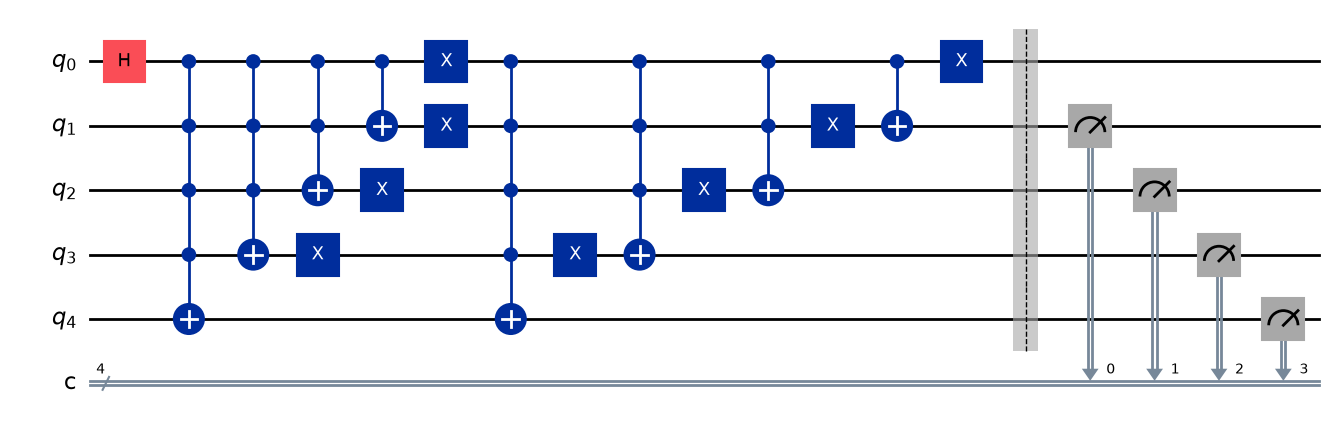

In [299]:
def oned_incr_operator(q_cir, pos_register):
    
    # Creates an increment operator for pos_register number of qubits
    
    num_of_controls = pos_register
    target = pos_register
    
    for i in range(0, pos_register):        
        controls = []
        
        for j in range(0, num_of_controls):
            controls.append(j)

        q_cir.mcx(control_qubits=controls,target_qubit=target)
        num_of_controls = num_of_controls - 1
        target = target - 1

def oned_decr_operator(q_cir, pos_register):
    
    # Creates an decrement operator for pos_register number of qubits

    num_of_controls = pos_register
    target = pos_register
    
    for i in range(0, pos_register):
        q_cir.x(i)
    
    for j in range(0, pos_register):        
        anti_controls = []
        
        for k in range(0, num_of_controls):
            anti_controls.append(k)

        q_cir.mcx(control_qubits=anti_controls,target_qubit=target)
        q_cir.x(target - 1)
        num_of_controls = num_of_controls - 1
        target = target - 1

def oned_steps(num_steps, q_cir, pos_register):
    
    # Runs a single step in the circuit

    for i in range(0, num_steps):
        q_cir.h(0)
        oned_incr_operator(q_cir, pos_register)
        oned_decr_operator(q_cir, pos_register)    

def oned_create_circuit(num_steps, pos_register):
    
    # Creates our quantum circuit
    
    q_cir = QuantumCircuit(1 + pos_register, pos_register)
    
    oned_steps(num_steps, q_cir, pos_register)
    
    q_cir.barrier()
    for i in range(0, pos_register):
        q_cir.measure(i + 1, i)
                
    return q_cir

def oned_run_circuit(q_cir, shots):

    # Runs a given circuit some shots number of times

    sampler = StatevectorSampler()
    result = sampler.run([q_cir], shots=shots).result()
    return result[0].data.c.get_counts()

position_register = 4
number_of_steps = 1
qc = oned_create_circuit(number_of_steps, position_register)

qc.draw(output="mpl")


Our rendition of the circuit is a 5 qubit version where a single qubit (qubit 0) is used for the coin state and four qubits are used to keep an eye on the walker's position (qubit 1-4). To perform a step, we implement an increment and decrement operator that acts on our position register depending on the result from a Hadamard coin. The increment operator is created by making a staircase of multi-qubit X gates as seen below. As for the decrement operator, it is the same as the increment, but we use anti-control qubits instead. You can implement anti-control qubits by surrounding the control qubits with X gates. We simply repeat these three operators for each time we wish to perform a step with our walker [2].

An interesting effect exists regarding the probability distribution of DTQW as we let it evolve over time. In a classical 1D random walk we expect a probability distribution to be gaussian, and for each additional step we add, the variance of that distribution increases. This is not the case for the quantum rendition of the walker. The distribution will contain a given bias to one of the sides of the distribution [1][2][3]. In the next code snippet, you'll see a bar plot containing the results for a quantum walk with a decidable number of qubits for the position register and steps.

In [300]:
def oned_plot_results(steps = 0, qubits = 1):
    
    qc = oned_create_circuit(steps, qubits)
    counts = oned_run_circuit(qc, shots=2048)
    
    states = []
    state_counts = []
    
    for i in range(0, 2**qubits):
        states.append(i)
        next_state_count = 0
        
        for j in counts:
            if i == int(j, 2):
                next_state_count = counts[j]

        state_counts.append(next_state_count)
    
    # To make sure that it is easier to see the distribution, I take the second half from states and 
    # state_counts and put them in front so the 0th position in both is centered.
    # I also convert each entry in states to strings so plt does not automatically put 0 to the left side of the plot
    
    first_half_states = states[:len(states)//2]
    second_half_states = states[len(states)//2:]

    first_half_states_count = state_counts[:len(states)//2]
    second_half_states_count = state_counts[len(states)//2:]
    
    centered_states = second_half_states + first_half_states
    centered_states = list(map(str, centered_states))
    centered_states_count = second_half_states_count + first_half_states_count

    print(centered_states)
    print(centered_states_count)
        
    plt.figure(figsize=(15, 3))
    plt.bar(centered_states, centered_states_count)




In [ ]:
widgets.interact(oned_plot_results,steps=(0,50,1), qubits=(1,8,1))


interactive(children=(IntSlider(value=0, description='steps', max=50), IntSlider(value=1, description='qubits'…

<function __main__.oned_plot_results(steps=0, qubits=1)>

You can see the effect of this bias for yourself by playing around with the size of the walking environment (qubits) and steps. For example if you put the slider to 4 qubits and gradually move the steps from 0 to 12 you'll see the state containing the most shots will move gradually to the left. 

We can very easily use the same methods for implementing the 1D Quantum Walk to implement a 2D Quantum Walk.

In [ ]:
# Quantum Walk on 2D graph

def twod_incr_operator(q_cir, register):
    
    num_of_controls = len(register) - 1
    target = max(register)
    
    for i in range(0, len(register)):
        controls = [0,1]
        
        for j in range(0, num_of_controls):
            controls.append(register[j])
        q_cir.mcx(control_qubits=controls,target_qubit=target)
        num_of_controls = num_of_controls - 1
        target = target - 1
    
def twod_decr_operator(q_cir, register):
    
    num_of_controls = len(register) - 1
    target = max(register)
    
    for i in range(0, len(register) - 1):
        q_cir.x(register[i])
    
    for j in range(0, len(register)):
        controls = [0,1]
        
        for k in range(0, num_of_controls):
            controls.append(register[k])

        #print("decr controls: ", controls)
        #print("decr targets: ", target)

        q_cir.mcx(control_qubits=controls,target_qubit=target)
        if target - 1 > min(register) - 1: # This tiny if statement is simply there to prevent the last X gate to be made. This is obviously not the best way to handle it but it'll work for now.
            q_cir.x(target - 1)
        num_of_controls = num_of_controls - 1
        target = target - 1

def twod_steps(q_cir, num_steps):
    
    # Runs a single step in the circuit

    full_register = []

    for i in range(2, q_cir.num_qubits):
        full_register.append(i)

    first_register = full_register[:len(full_register)//2]    
    second_register = full_register[len(full_register)//2:]
    
    #print("First Register: ", first_register)
    #print("Second Register: ", second_register)
    
    for i in range(0, num_steps):
        q_cir.h(0)
        q_cir.h(1)
        twod_incr_operator(q_cir, first_register)
        q_cir.x(1)
        twod_decr_operator(q_cir, first_register)
        q_cir.x(1)
        q_cir.x(0)
        twod_incr_operator(q_cir, second_register)
        q_cir.x(1)
        twod_decr_operator(q_cir, second_register)
        q_cir.x(1)
        q_cir.x(0)


def twod_create_circuit(num_steps, position_register_qubits):
    
    # Creates our quantum circuit
    
    q_cir = QuantumCircuit(2 + 2**position_register_qubits, 2**position_register_qubits)
    
    twod_steps(q_cir, num_steps)
    
    q_cir.barrier()
    
    full_register = []

    for i in range(2, q_cir.num_qubits):
        full_register.append(i)

    for j in range(0, len(full_register)):
        q_cir.measure(full_register[j],j)
    #for i in range(0, q_cir.num_qubits):
    #    q_cir.measure(i, i)
                
    return q_cir

def twod_run_circuit(q_cir, shots):

    # Runs a given circuit some shots number of times

    sampler = StatevectorSampler()
    result = sampler.run([q_cir], shots=shots).result()
    return result[0].data.c.get_counts()

position_register_qubits = 2
number_of_steps = 10
qc = twod_create_circuit(number_of_steps, position_register_qubits)

qc.draw(output="mpl")

#counts = twod_run_circuit(qc, shots=1024)
#print("Counts: ", counts)
#twod_run_circuit(qc, shots=2048)

#Plot
    



Counts:  {'0111': 72, '1010': 474, '1111': 46, '1101': 61, '0000': 177, '0010': 60, '0101': 66, '1000': 68}


In [303]:
def twod_plot_results(number_of_steps=0, position_register_qubits=2):
    qc = twod_create_circuit(number_of_steps, position_register_qubits)

    #qc.draw(output="mpl")

    counts = twod_run_circuit(qc, shots=1024)

    count_keys = list(counts.keys())
    
    print(count_keys)
    
    x_positions = []
    y_positions = []
    state_counts = []
    
    for i in range(0, len(counts)):
    
        #print("Iter ", i)
        first_half  = count_keys[i][:len(count_keys[i])//2]
        second_half = count_keys[i][len(count_keys[i])//2:]
        #print("first_half ", first_half)
        #print("first_half ", int(first_half, 2))
        #print("second_half ", second_half)
        #print("second_half ", int(second_half, 2))
        #print("Counts", counts[count_keys[i]])
        x_positions.append(int(first_half, 2))
        y_positions.append(int(second_half, 2))

        state_counts.append(counts[count_keys[i]])
    
        #x_positions.append(i)
        #y_positions.append(i)

        pass

    print("x_positions", x_positions)
    print("y_positions", y_positions)
    print("y_positions", state_counts)

    #setting the 3D axes
    fig = plt.figure(figsize=(15, 3))
    ax1 = fig.add_subplot(111, projection='3d')

    #data preparation
    xpos = x_positions
    ypos = y_positions
    #num_elements = len(xpos)
    zpos = np.zeros(len(x_positions))
    dx = np.ones(len(x_positions))
    dy = np.ones(len(y_positions))
    dz = state_counts

    #plotting
    ax1.bar3d(xpos, ypos, zpos, dx, dy, dz, color='hotpink')
    #ax1.set_xlim(0, len(x_positions) // 2)
    #ax1.set_ylim(0, len(y_positions) // 2)
    plt.show()

In [304]:
widgets.interact(twod_plot_results,number_of_steps=(0,50,1), position_register_qubits=(1,4,1))


interactive(children=(IntSlider(value=0, description='number_of_steps', max=50), IntSlider(value=2, descriptio…

<function __main__.twod_plot_results(number_of_steps=0, position_register_qubits=2)>

## Continuous-Time Quantum Walks

CTQW

## Real Application (Search in Database)

# References


[1]: Qiang, X., Ma, S., Song H. (2024) Quantum Walk Computing: Theory,
Implementation, and Application. Available at: https://spj.science.org/doi/full/10.34133/icomputing.0097

[2]: Hundt, R. (2022) Quantum Computing for Programmers

[3]: Montanaro, A. (2011) Quantum walks

[4]: De Wolf, R. (2019) Quantum Computing: Lecture Notes. Available at: https://arxiv.org/abs/1907.09415

[5]: QuEra (N/A) Quantum Walk. Available at: https://www.quera.com/glossary/quantum-walk#heading-1

[6]: Google Quantum AI (2026) Quantul walk. Available at: https://quantumai.google/cirq/experiments/quantum_walks
